In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [25]:
# Cấu hình font chữ
plt.rcParams['font.family'] = 'Georgia'

In [26]:
# Đọc dữ liệu
df = pd.read_csv("../data/processed/Cleaned_Global_Cybersecurity_Threats_2015-2024.csv")

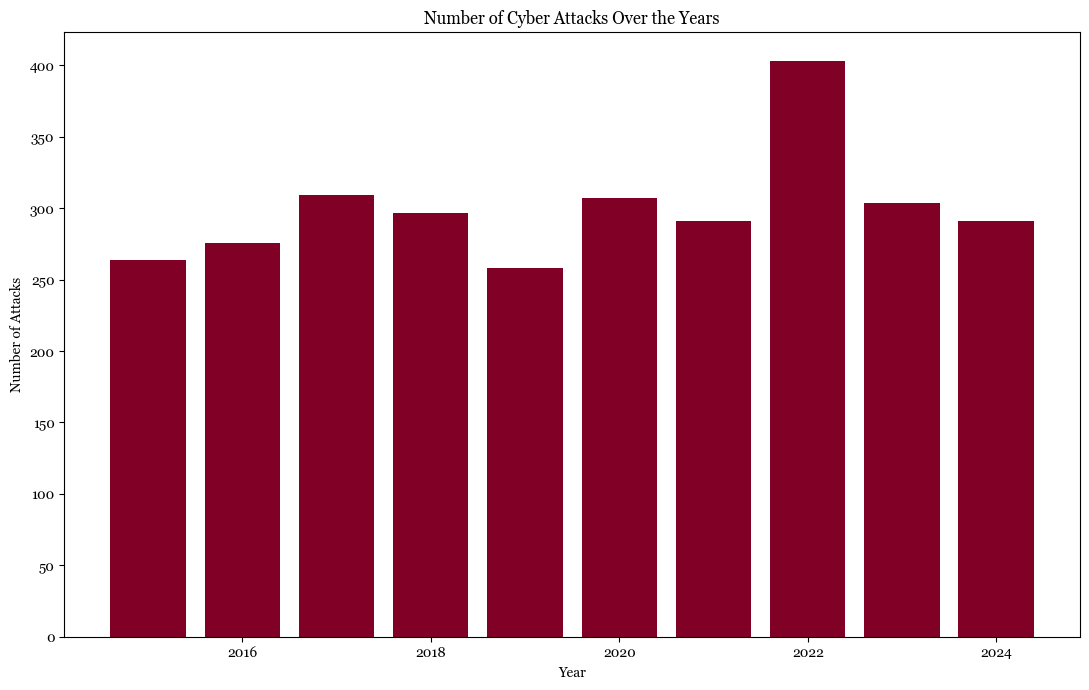

In [27]:
# --- Biểu đồ số lượng tấn công theo năm ---
attacks_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(11, 7))
plt.bar(attacks_per_year.index, attacks_per_year.values, color='#800026')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Number of Cyber Attacks Over the Years")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# --- Thống kê phần trăm các loại hình tấn công ---
attack_counts = df['Attack Type'].value_counts(normalize=True) * 100
attack_counts = attack_counts.round(1)

print("Tỷ lệ phần trăm các loại hình tấn công:")
print(attack_counts)

Tỷ lệ phần trăm các loại hình tấn công:
Attack Type
Phishing             20.0
Ddos                 17.0
Sql Injection        16.3
Ransomware           16.0
Malware              15.9
Man-In-The-Middle    14.8
Name: proportion, dtype: float64


In [29]:
# --- Bản đồ các quốc gia bị tấn công nhiều nhất ---
country_attacks = df['Country'].str.strip().value_counts().reset_index()
country_attacks.columns = ['Country', 'Attack count']

fig = px.choropleth(
    country_attacks,
    locations='Country',
    locationmode='country names',
    color='Attack count',
    color_continuous_scale='ylorrd',
    title='Map of Most Attacked Countries'
)
fig.update_layout(margin={"l": 20, "r": 20, "t": 40, "b": 20})
fig.show()

In [30]:
print("Tổng thiệt hại:", df['Financial Loss (in Million $)'].sum(), )
print("Số người dùng bị ảnh hưởng:", df['Number of Affected Users'].sum(),)

Tổng thiệt hại: 151799.74
Số người dùng bị ảnh hưởng: 1514903685.0


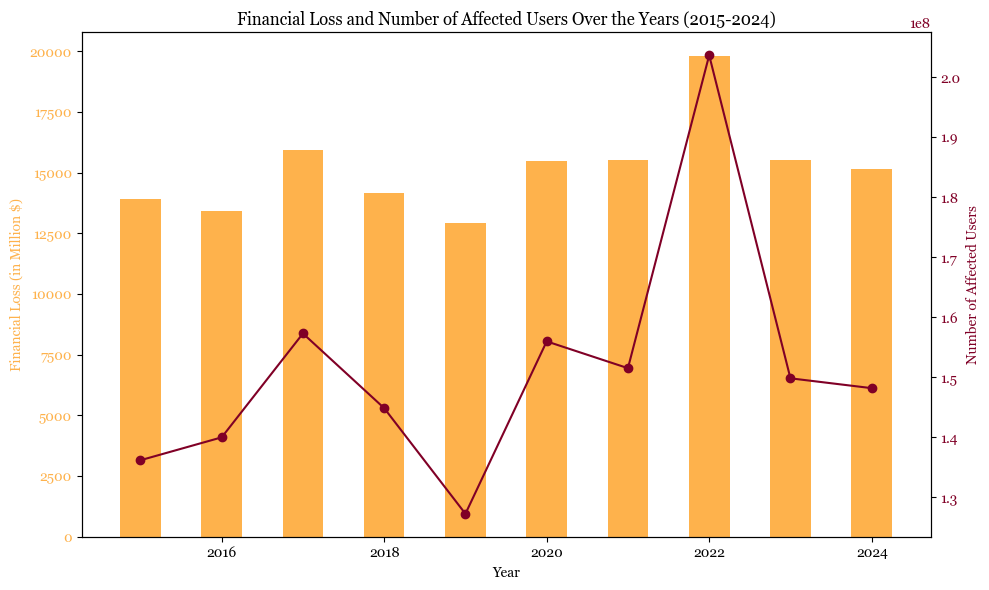

In [31]:
# --- Tổng quan về thiệt hại tài chính và số người dùngdùng bị ảnh hưởng (2015–2024) ---
grouped_data = df.groupby('Year')[['Financial Loss (in Million $)', 'Number of Affected Users']].sum()

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(grouped_data.index, grouped_data['Financial Loss (in Million $)'], color='#feb24c', label='Financial Loss (in Million $)', width=0.5)
ax1.set_xlabel('Year')
ax1.set_ylabel('Financial Loss (in Million $)', color='#feb24c')
ax1.tick_params(axis='y', labelcolor='#feb24c')

ax2 = ax1.twinx()
ax2.plot(grouped_data.index, grouped_data['Number of Affected Users'], color='#800026', label='Number of Affected Users', marker='o')
ax2.set_ylabel('Number of Affected Users', color='#800026')
ax2.tick_params(axis='y', labelcolor='#800026')


plt.title('Financial Loss and Number of Affected Users Over the Years (2015-2024)')
fig.tight_layout()
plt.show()

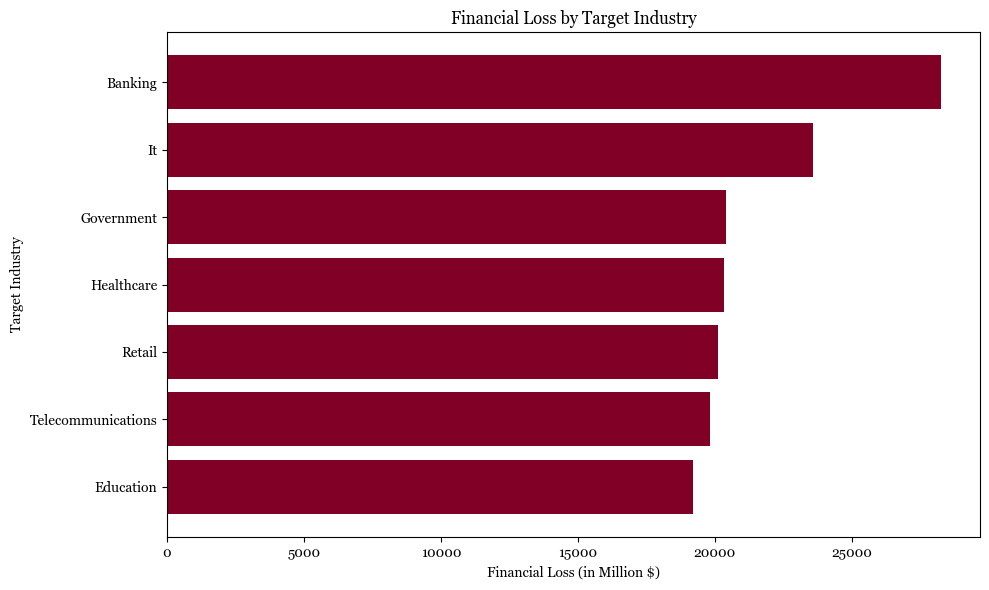

In [32]:
# --- Thiệt hại phân theo ngành --- 
industry_loss = df.groupby('Target Industry')['Financial Loss (in Million $)'].sum().reset_index()

industry_loss = industry_loss.sort_values(by='Financial Loss (in Million $)', ascending=False)

max_loss_index = industry_loss['Financial Loss (in Million $)'].idxmax()

colors = ['#800026']

plt.figure(figsize=(10, 6))
plt.barh(industry_loss['Target Industry'], industry_loss['Financial Loss (in Million $)'], color=colors)
plt.xlabel('Financial Loss (in Million $)')
plt.ylabel('Target Industry')
plt.title('Financial Loss by Target Industry')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

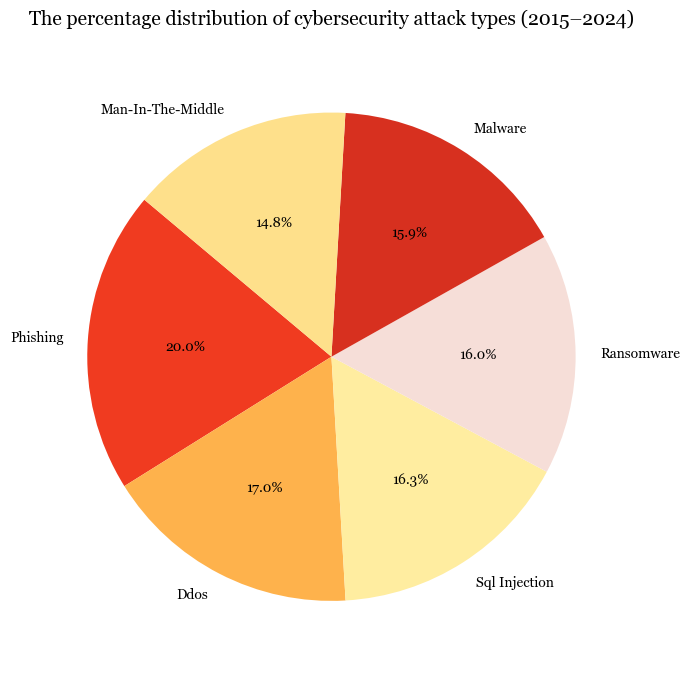

In [33]:
# --- Hình thức tấn công ---
attack_counts = df['Attack Type'].value_counts()

colors=['#f03b20', '#feb24c', '#ffeda0', '#F6DED8', '#d7301f','#fee08b']
plt.figure(figsize=(7, 7))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%', startangle=140, colors = colors)
plt.title('The percentage distribution of cybersecurity attack types (2015–2024)', fontsize=14)
plt.axis('equal')  
plt.tight_layout()
plt.show()

In [34]:
#--- Tính toán số liệu ---
print(f"Financial Loss (in Million $): {df['Financial Loss (in Million $)'].sum()}")

print(f"Number of Affected Users: {df['Number of Affected Users'].sum()}")

Financial Loss (in Million $): 151799.74
Number of Affected Users: 1514903685.0


<Figure size 700x700 with 0 Axes>

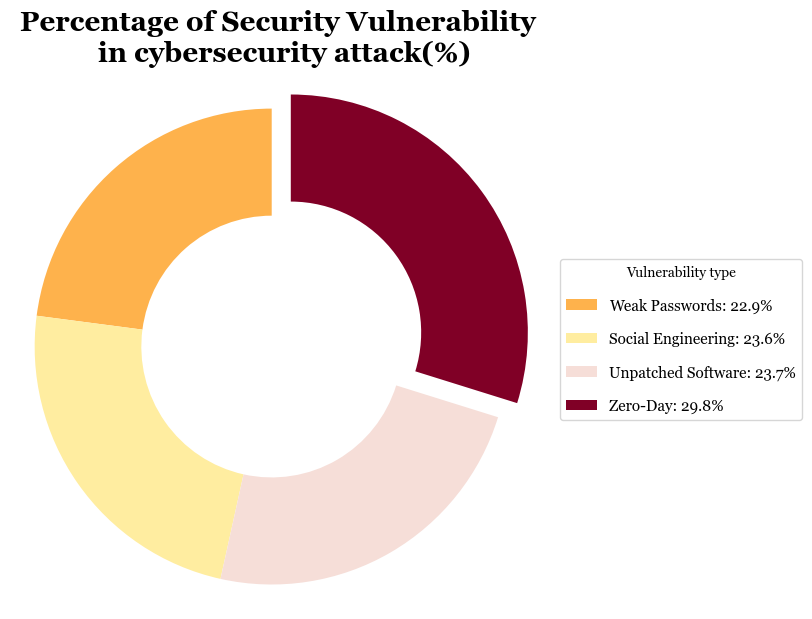

In [35]:
#--- Tỉ lệ phần trăm nguyên nhân của các cuộc tấn công ---
reasoncount=df['Security Vulnerability Type'].value_counts().sort_values()
labels = reasoncount.index.tolist()
sizes = reasoncount.values
plt.figure(figsize=(7,7))
colors = [ '#feb24c', '#ffeda0','#F6DED8','#800026'] 
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts = ax.pie(
    sizes,
    labels=None,  # ẩn nhãn trực tiếp trên lát
    colors=colors,
    startangle=90, 
    pctdistance=0.75,
    wedgeprops={'width': 0.45},
    explode=[0,0,0,0.1],
    textprops={ 'fontsize': 16}
)
ax.legend(
    wedges,
    [f"{label}: {size/sum(sizes):.1%}" for label, size in zip(labels, sizes)],
    title="Vulnerability type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),  # đưa sang phải
    labelspacing=1.2,
    fontsize=11
)
plt.title('Percentage of Security Vulnerability \n in cybersecurity attack(%)', fontsize=20, fontweight='bold')

plt.axis('equal')  # Đảm bảo hình tròn

plt.show()


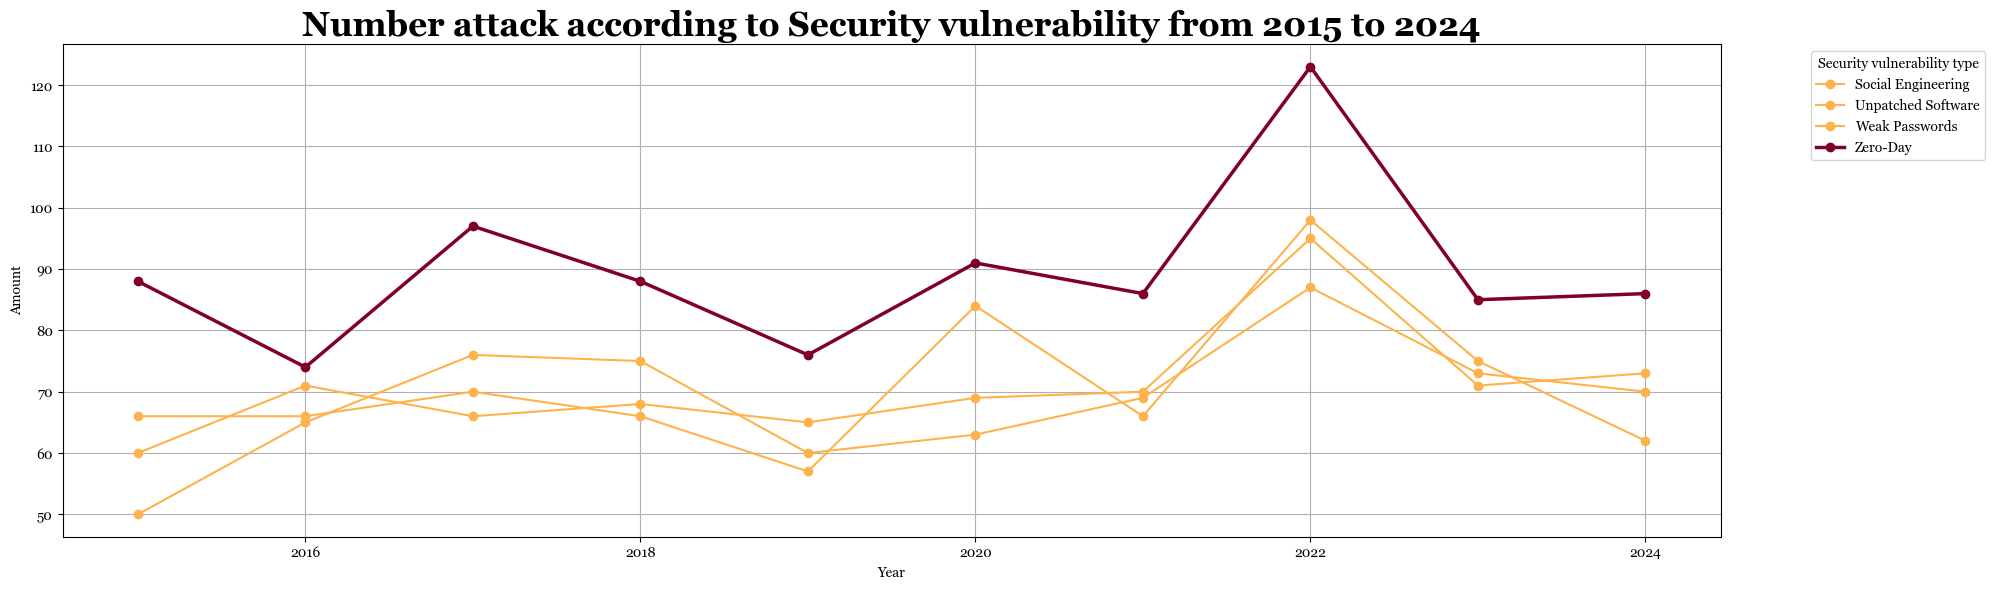

In [ ]:
# Số lượng tấn công theo từng loại lỗ hổng bảo mật từ 2015 đến 2024
# Đếm số lượng lỗ hổng theo từng năm
vuln_by_year = df.groupby(['Year', 'Security Vulnerability Type']).size().reset_index(name='Count')

# Pivot để mỗi dòng là năm, mỗi cột là loại lỗ hổng
vuln_pivot = vuln_by_year.pivot(index='Year', columns='Security Vulnerability Type', values='Count').fillna(0)

# Vẽ biểu đồ đường
plt.figure(figsize=(20, 6))
for col in vuln_pivot.columns:
    if col == 'Zero-Day':
        plt.plot(vuln_pivot.index, vuln_pivot[col], marker='o', label=col, color='#800026', linewidth=2.5)
    else:
        plt.plot(vuln_pivot.index, vuln_pivot[col], marker='o', label=col,color ='#feb24c', linewidth=1.5)
plt.title('Number attack according to Security vulnerability from 2015 to 2024', fontsize=24, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend(title='Security vulnerability type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

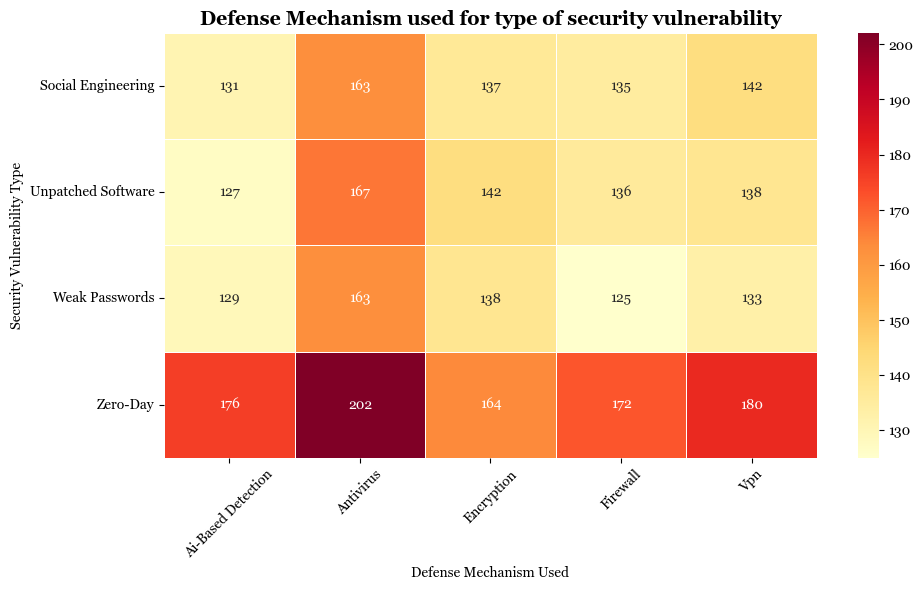

In [ ]:
# Biểu đồ phòng thủ áp dụng cho từng loại lỗ hổng 
heatmap_data = df.groupby(['Security Vulnerability Type', 'Defense Mechanism Used']).size().unstack(fill_value=0)

# Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap= 'YlOrRd' , linewidths=0.5)

plt.title('Defense Mechanism used for type of security vulnerability', fontsize=14, fontweight='bold')
plt.xlabel('Defense Mechanism Used')
plt.ylabel('Security Vulnerability Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

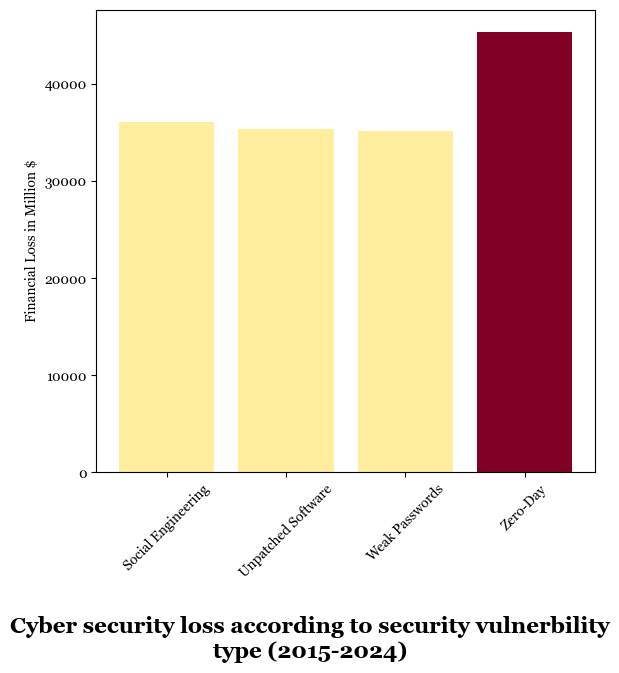

In [38]:
# Financial loss theo lỗ hổng
finan_los_type=df[['Financial Loss (in Million $)','Security Vulnerability Type']].groupby('Security Vulnerability Type').sum()
max_loss = finan_los_type['Financial Loss (in Million $)'].idxmax()

# Tạo danh sách màu: nếu index là cột cao nhất thì dùng màu khác, còn lại dùng màu mặc định
colors = ['#800026' if i == max_loss else'#ffeda0' for i in finan_los_type.index]

# Vẽ biểu đồ
plt.figure(figsize=(6,6))
bars = plt.bar(finan_los_type.index, finan_los_type['Financial Loss (in Million $)'], color=colors)
plt.figtext(0.5, -0.1, 'Cyber security loss according to security vulnerbility type (2015-2024)',
            wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
plt.ylabel('Financial Loss in Million $')
plt.xticks(rotation=45, )
plt.tight_layout()

plt.show()


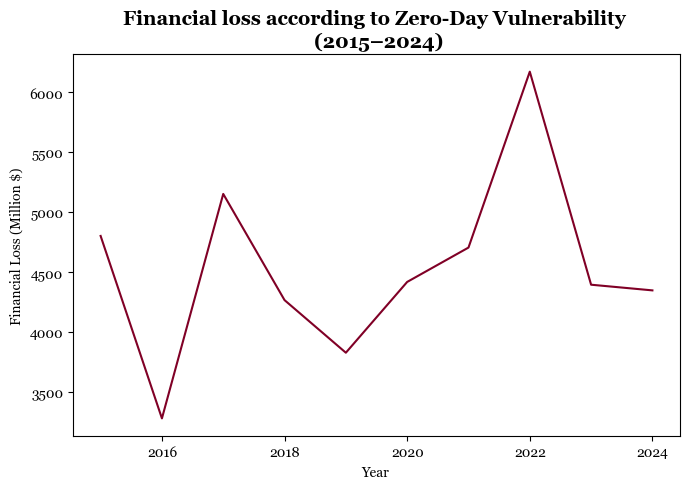

In [39]:
# Thiệt hại theo năm bởi lỗ hổng Zero-Day
filtered_data = df[df['Security Vulnerability Type'] == 'Zero-Day']
zero_day_loss_by_year = filtered_data.groupby('Year')['Financial Loss (in Million $)'].sum().reset_index()
# Vẽ biểu đồ
plt.figure(figsize=(7,5))
bars = plt.plot(zero_day_loss_by_year['Year'], zero_day_loss_by_year['Financial Loss (in Million $)'], color='#800026')

plt.title('Financial loss according to Zero-Day Vulnerability \n (2015–2024)', fontsize=14, fontweight='bold')
plt.ylabel('Financial Loss (Million $)' )
plt.xlabel('Year ' )
plt.xticks()
plt.yticks()
plt.tight_layout()

plt.show()

In [40]:
finan_los_type.head()

,Financial Loss (in Million $)
Security Vulnerability Type,
Social Engineering,36081.93
Unpatched Software,35304.39
Weak Passwords,35065.83
Zero-Day,45347.59


In [ ]:
# Số lượng các vụ tấn công gây ra bởi lỗ hổng bảo mật : Zero-Day theo loại hình tấn công
filtered_data = df[df['Security Vulnerability Type'] == 'Zero-Day']
numbersecurity=filtered_data[['Security Vulnerability Type','Attack Type']].groupby('Attack Type').count()
numbersecurity 

,Security Vulnerability Type
Attack Type,
Ddos,136
Malware,158
Man-In-The-Middle,127
Phishing,201
Ransomware,126
Sql Injection,146


In [42]:
numbersecurity['Security Vulnerability Type']

Attack Type
Ddos                 136
Malware              158
Man-In-The-Middle    127
Phishing             201
Ransomware           126
Sql Injection        146
Name: Security Vulnerability Type, dtype: int64

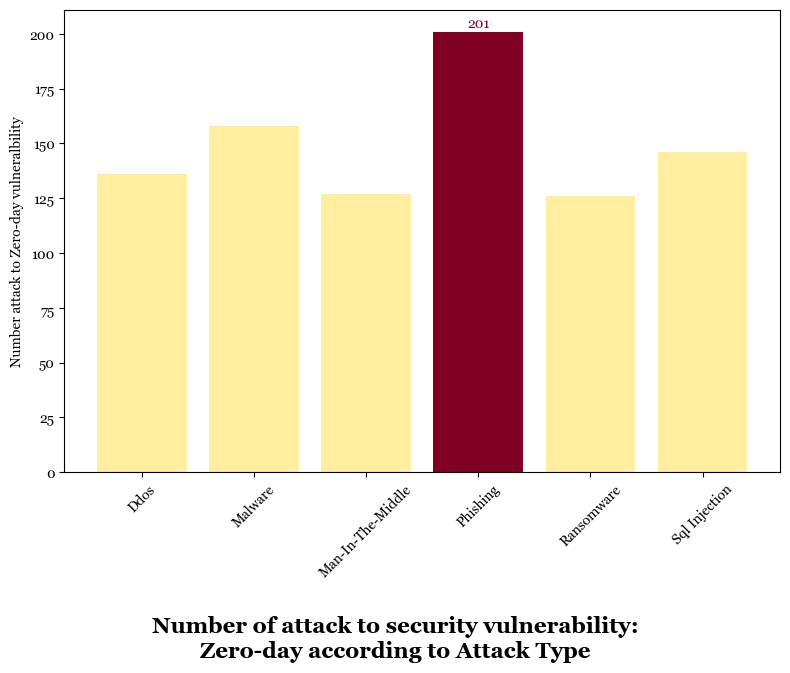

In [ ]:
#Biểu đồ ssố lượng các vụ tấn công gây ra bởi lỗ hổng bảo mật : Zero-Day theo loại hình tấn công
max_index = numbersecurity['Security Vulnerability Type'].idxmax()

colors = ['#800026' if i == max_index else '#ffeda0' for i in numbersecurity.index]

# Vẽ biểu đồ
plt.figure(figsize=(8,6))
bars = plt.bar(numbersecurity.index, numbersecurity['Security Vulnerability Type'], color=colors)
plt.figtext(0.5, -0.1, 'Number of attack to security vulnerability:\nZero-day according to Attack Type',
            wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
plt.ylabel('Number attack to Zero-day vulneralbility')
plt.xticks(rotation=45, )
plt.tight_layout()


max_value = numbersecurity['Security Vulnerability Type'].max()
max_x = list(numbersecurity.index).index(max_index)  # vị trí theo thứ tự cột

# Hiển thị giá trị ngay trên đỉnh cột cao nhất
plt.text(max_x, max_value + 0.5, f'{max_value}', ha='center', va='bottom', fontsize=10,color='#800026')
plt.show()

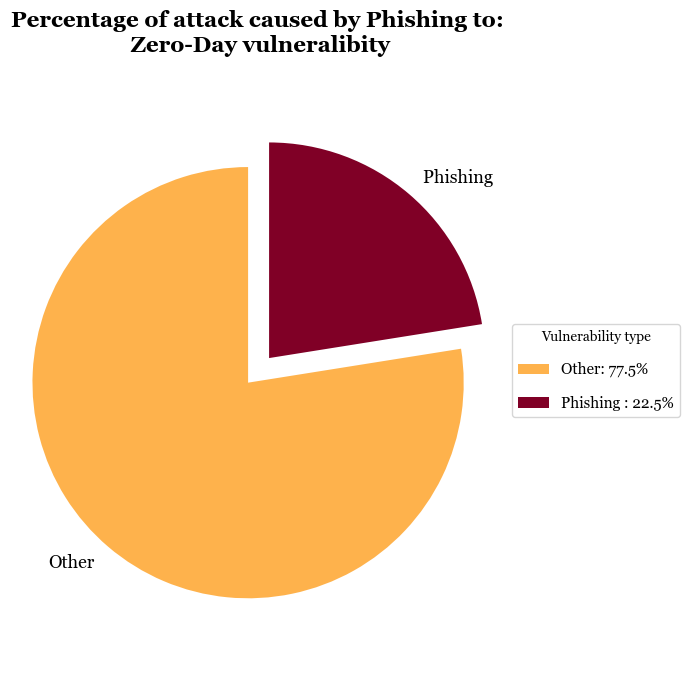

In [ ]:
# Phần trăm PPhishing trong Zero-Day
attack_counts = filtered_data['Attack Type'].value_counts().sort_values(ascending=False)

# Lấy số lượng Phishing và Other
phishing_count = attack_counts.get('Phishing', 0)
other_count = attack_counts.sum() - phishing_count

# Tạo dữ liệu cho biểu đồ
labels = ['Other', 'Phishing ']
sizes = [other_count, phishing_count]
colors = ['#feb24c', '#800026']  # màu đỏ đậm cho Phishing, đỏ nhạt cho phần còn lại

# Vẽ biểu đồ tròn
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts= ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=[0,0.15],
    startangle=90,
    textprops={'color': 'black', 'fontsize': 13},
   
)
ax.legend(
    wedges,
    [f"{label}: {size/sum(sizes):.1%}" for label, size in zip(labels, sizes)],
    title="Vulnerability type",
    loc="center left", 
    bbox_to_anchor=(1, 0.5),  # đưa sang phải
    labelspacing=1.2,
    fontsize=11)
# Tiêu đề
ax.set_title('Percentage of attack caused by Phishing to:\n Zero-Day vulneralibity',
             fontsize=16,fontweight='bold')

ax.axis('equal')  # đảm bảo hình tròn
plt.tight_layout()
plt.show()